# Benchmark: np.memmap vs struct.unpack

fastEIT parses Dräger `.bin` files using `np.memmap`, the OS maps the file
directly into virtual memory as a numpy structured array, with no Python loop
and no intermediate copy.

This notebook benchmarks that approach against the classic alternative:
reading the file into a bytes buffer and unpacking frame-by-frame with
`struct.unpack_from` in a Python loop.

Both approaches extract the same data: the `(N, 32, 32)` pixel array for
every frame. Only the parsing strategy differs.

**File sizes tested:** 10 MB - 50 MB - 100 MB - 250 MB  
**Frame format:** Dräger BASE (4358 bytes/frame, 1024 float32 pixels per frame)

In [1]:
import struct     
import tempfile    
import time        
import tracemalloc  
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Import the actual dtype from fastEIT
from fasteit.parsers.draeger.bin.draeger_dtypes import FRAME_BASE_DTYPE

## Configuration

In [2]:
FRAME_SIZE  = 4358  

TARGET_MB    = [10, 50, 100, 250]
FRAME_COUNTS = [int(mb * 1024**2) // FRAME_SIZE for mb in TARGET_MB]
FILE_SIZES_MB = [n * FRAME_SIZE / 1024**2 for n in FRAME_COUNTS]

print(f"{'Target':>10}  {'Frames':>8}  {'Actual MB':>10}")
for mb, n, actual in zip(TARGET_MB, FRAME_COUNTS, FILE_SIZES_MB):
    print(f"{mb:>8} MB  {n:>8}  {actual:>9.2f} MB")

    Target    Frames   Actual MB
      10 MB      2406      10.00 MB
      50 MB     12030      50.00 MB
     100 MB     24060     100.00 MB
     250 MB     60152     250.00 MB


## Generate synthetic .bin files


In [3]:
def make_synthetic_bin(path: Path, n_frames: int) -> None:
    """Write n_frames of random data in Dräger BASE dtype format."""
    rng = np.random.default_rng(seed=42)  # fixed seed = reproducible
    frames = np.zeros(n_frames, dtype=FRAME_BASE_DTYPE)
    frames["ts"]           = rng.uniform(0.5, 0.9, n_frames)
    frames["pixels"]       = rng.standard_normal((n_frames, 32, 32)).astype(np.float32)
    frames["medibus_data"] = rng.standard_normal((n_frames, 52)).astype(np.float32)
    frames.tofile(str(path))  # raw binary dump, no header

tmpdir   = Path(tempfile.mkdtemp())
bin_files = {}

for n, mb in zip(FRAME_COUNTS, TARGET_MB):
    p = tmpdir / f"synthetic_{mb}mb.bin"
    make_synthetic_bin(p, n)
    bin_files[mb] = p
    print(f"Generated {mb:>4} MB target → {p.stat().st_size / 1024**2:.2f} MB, {n} frames")

Generated   10 MB target → 10.00 MB, 2406 frames
Generated   50 MB target → 50.00 MB, 12030 frames
Generated  100 MB target → 100.00 MB, 24060 frames
Generated  250 MB target → 250.00 MB, 60152 frames


## The two parsing strategies

### Approach A - np.memmap

`np.memmap(path, dtype=..., mode='r', shape=(...))` asks the OS to map the file
into the process address space as a structured array. 

### Approach B - struct.unpack_from loop

`path.read_bytes()` loads the **entire file** into a Python `bytes` object in RAM.
Then `struct.unpack_from(fmt, buffer, offset)` decodes one frame at a time,
returning a Python tuple. 

In [ ]:
def parse_memmap(path: Path) -> np.ndarray:
    n_frames = path.stat().st_size // FRAME_SIZE
    # Map file as structured array — zero-copy, OS handles paging
    # Sentinel values are preserved: replacement is deferred to preprocessing layer
    mapped = np.memmap(path, dtype=FRAME_BASE_DTYPE, mode="r", shape=(n_frames,))
    return mapped["pixels"]


_STRUCT_FMT  = "<d f 1024f i i 30s i 52f"

def parse_struct_loop(path: Path) -> np.ndarray:
    raw      = path.read_bytes()            # load entire file into RAM as bytes
    n_frames = len(raw) // FRAME_SIZE
    pixels   = np.empty((n_frames, 32, 32), dtype=np.float32)
    for i in range(n_frames):
        unpacked  = struct.unpack_from(_STRUCT_FMT, raw, offset=i * FRAME_SIZE)
        pixels[i] = np.array(unpacked[2:1026], dtype=np.float32).reshape(32, 32)
    return pixels

## Run benchmarks

`time.perf_counter()` measures wall-clock time with nanosecond resolution.

`tracemalloc` is Python's built-in memory profiler: `start()` begins tracking
all allocations, `get_traced_memory()` returns `(current, peak)` in bytes,
`stop()` ends tracking. Peak RAM is the maximum memory allocated at any single
point during the call.

In [5]:
results = []

for mb in TARGET_MB:
    path = bin_files[mb]
    n    = FRAME_COUNTS[TARGET_MB.index(mb)]
    print(f"\n── {mb} MB ({n} frames) ────────────────")

    # ── Time ────────────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    parse_memmap(path)
    t_memmap = time.perf_counter() - t0

    t0 = time.perf_counter()
    parse_struct_loop(path)
    t_struct = time.perf_counter() - t0

    print(f"  memmap:      {t_memmap:.3f} s")
    print(f"  struct loop: {t_struct:.3f} s")

    # ── RAM ─────────────────────────────────────────────────────────────────
    tracemalloc.start()
    parse_memmap(path)
    _, peak_mm = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    tracemalloc.start()
    parse_struct_loop(path)
    _, peak_st = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    print(f"  RAM memmap:  {peak_mm / 1024**2:.1f} MB")
    print(f"  RAM struct:  {peak_st / 1024**2:.1f} MB")

    results.append(dict(
        mb=mb, n=n,
        t_memmap=t_memmap, t_struct=t_struct,
        ram_memmap=peak_mm / 1024**2, ram_struct=peak_st / 1024**2,
    ))

print("\nDone.")


── 10 MB (2406 frames) ────────────────
  memmap:      0.000 s
  struct loop: 0.071 s
  RAM memmap:  0.0 MB
  RAM struct:  19.5 MB

── 50 MB (12030 frames) ────────────────
  memmap:      0.000 s
  struct loop: 0.345 s
  RAM memmap:  0.0 MB
  RAM struct:  97.1 MB

── 100 MB (24060 frames) ────────────────
  memmap:      0.000 s
  struct loop: 0.770 s
  RAM memmap:  0.0 MB
  RAM struct:  194.0 MB

── 250 MB (60152 frames) ────────────────
  memmap:      0.000 s
  struct loop: 1.708 s
  RAM memmap:  0.0 MB
  RAM struct:  485.0 MB

Done.


## Plots

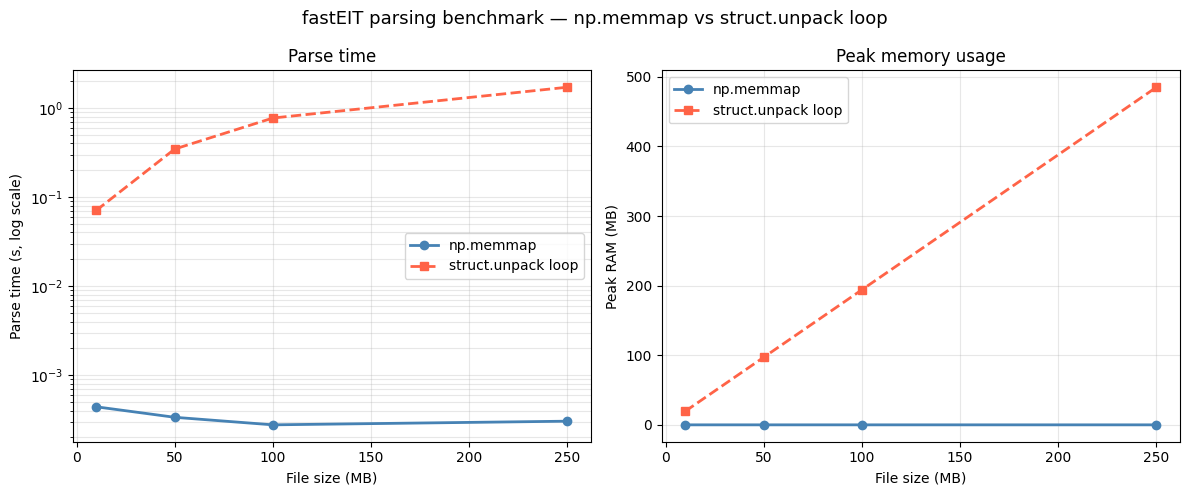

In [6]:
sizes  = [r["mb"]         for r in results]
t_mm   = [r["t_memmap"]   for r in results]
t_st   = [r["t_struct"]   for r in results]
ram_mm = [r["ram_memmap"] for r in results]
ram_st = [r["ram_struct"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("fastEIT parsing benchmark — np.memmap vs struct.unpack loop", fontsize=13)

# Plot 1: parse time (log scale)
ax = axes[0]
ax.plot(sizes, t_mm, "o-",  label="np.memmap",         color="steelblue", lw=2)
ax.plot(sizes, t_st, "s--", label="struct.unpack loop", color="tomato",   lw=2)
ax.set_yscale("log")
ax.set_xlabel("File size (MB)")
ax.set_ylabel("Parse time (s, log scale)")
ax.set_title("Parse time")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# Plot 2: peak RAM
ax = axes[1]
ax.plot(sizes, ram_mm, "o-",  label="np.memmap",         color="steelblue", lw=2)
ax.plot(sizes, ram_st, "s--", label="struct.unpack loop", color="tomato",   lw=2)
ax.set_xlabel("File size (MB)")
ax.set_ylabel("Peak RAM (MB)")
ax.set_title("Peak memory usage")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretation

memmap is faster and uses less RAM across all file sizes tested.

**Why memmap is fast:** `np.memmap` sets up a virtual address space mapping. The OS loads file pages on demand. `parse_memmap()` returns a lazy view of the pixel field: no data is actually read from disk until accessed; the mapping is read-only.

**Why struct.unpack is slower:** `path.read_bytes()` loads the entire file into a Python `bytes` buffer in RAM before any parsing begins. Every frame then requires one `struct.unpack_from` call and one tuple allocation.

struct peak RAM grows linearly: one full `bytes` buffer + one pixel array.
memmap peak RAM is near zero: only the virtual mapping is set up, no pixel array is allocated in RAM.

This could be useful to separate completely the parsing layer and the preprocessing layer. The computational cost stays entirely in the preprocessing layer, avoiding extra overhead when parsing more than one file. You will pay the computational cost only on the file you intend to work on, and only when you start working on it.